# Notebook Regresion Lineal 2 Reto: Interlub
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)


## Instrucciones:
- Active su entorno de `conda`
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código

In [1]:
# cargar librerías básicas
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro
import pandas as pd

# 1. Base de datos numerica
*Ejercicio:* Cargue los datos previamente preparados 100% numericos

In [2]:
df = pd.read_csv("transformed_data_interlub.csv")

## 2. Generacion de datos mas avanzada

### 2.1. Simulacion mediante KNN 

*Ejercicio:* Agregar explicacion detallada del algoritmo y de la funcion

In [3]:
def simular_datos_knn(df_original, n_nuevos=100, k=5):
    """
    documentar
    """
    X = df_original.to_numpy(dtype=float)

    # normalizaicion basica
    n, d = X.shape
    mean = X.mean(axis=0)
    std = X.std(axis=0) + 1e-8
    Xn = (X - mean) / std

    nuevos = []
    for _ in range(n_nuevos):
        base = Xn[np.random.randint(0, n)]               # en esta linea se escoge un punto base aleatorio 
        dist = np.sqrt(np.sum((Xn - base) ** 2, axis=1)) # se calcula la distancia euclidiana entre el punto base y todos los puntos
        vecinos_idx = np.argsort(dist)[1:k+1]            # se obtienen los indices de los k vecinos más cercanos
        vecino = Xn[np.random.choice(vecinos_idx)]       # se escoge un vecino aleatorio entre los k vecinos más cercanos
        nuevo = base + np.random.rand() *(vecino - base) # se genera un nuevo punto entre el punto base y el vecino
        nuevos.append(nuevo)

    nuevos = np.array(nuevos)
    # quitar norm,.
    X_new = nuevos * std + mean

    df_nuevo = pd.DataFrame(X_new, columns=df_original.columns)
    return df_nuevo


### 2.2. Simulacion mediante Gaussian Copulas

Ejercicios:
- Describa para que nos sirven las copulas gaussianas
- Revise la documentacion https://sdv.dev/Copulas/
- Encuentre que funciones podrian mejorar la funcionalidad en la funcion que escribio el profesor abajo


In [4]:
#pip install copulas

In [5]:
from copulas.multivariate import GaussianMultivariate
import pandas as pd

def simular_datos_copula(df_original, n_nuevos=100):
    """
    escriba documentacion adecuada
    """
    model = GaussianMultivariate() # crea el modelo de copula gaussiana
    model.fit(df_original) # ajusta el modelo a los datos originales
    df_nuevo = model.sample(n_nuevos) # genera nuevas muestras
    return df_nuevo

### 2.3. Simulacion con Variational AutoEncoder 

Los VAE aprenden un espacio latente continuo del cual se puede muestrear.

Muy útiles si tus datos tienen una estructura suave (por ejemplo, mediciones físicas).

In [6]:
#pip install torch

In [7]:
import torch
from torch import nn

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, latent_dim * 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def encode(self, x):
        mu_logvar = self.encoder(x)
        mu, logvar = mu_logvar.chunk(2, dim=-1)
        logvar = torch.clamp(logvar, min=-10, max=10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


def simular_datos_vae(df_original, n_nuevos=100, latent_dim=5, epochs=500, lr=1e-4):
    """
    documentar
    """
    df_num = df_original.select_dtypes(include=np.number).replace(-99, np.nan)
    df_num = df_num.fillna(df_num.mean())
    X = df_num.values

    # comentar
    mean = X.mean(axis=0)
    std = X.std(axis=0) + 1e-8
    X_norm = (X - mean) / std

    # comentar
    X_tensor = torch.tensor(X_norm, dtype=torch.float32)

    vae = VAE(input_dim=X.shape[1], latent_dim=latent_dim)
    # comentar
    optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

    def loss_fn(recon_x, x, mu, logvar):
        recon_loss = nn.functional.mse_loss(recon_x, x) # comentar
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp()) # comentar
        return recon_loss + kl_loss

    for epoch in range(epochs):
        optimizer.zero_grad()
        recon_x, mu, logvar = vae(X_tensor)
        loss = loss_fn(recon_x, X_tensor, mu, logvar)
        loss.backward()
        optimizer.step()

        if torch.isnan(loss):
            break

    # generacion de datos
    with torch.no_grad():
        z = torch.randn(n_nuevos, latent_dim)
        X_new_norm = vae.decoder(z).numpy()

    # quitar la norm,.
    X_new = X_new_norm * std + mean
    return pd.DataFrame(X_new, columns=df_num.columns)


# 3. Regresión lineal

### 3.1 Definir, probar el modelo y graficar resultados

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:6730: RuntimeWarning: divide by zero encountered in power
  return cd2*x**(c-1)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iteration

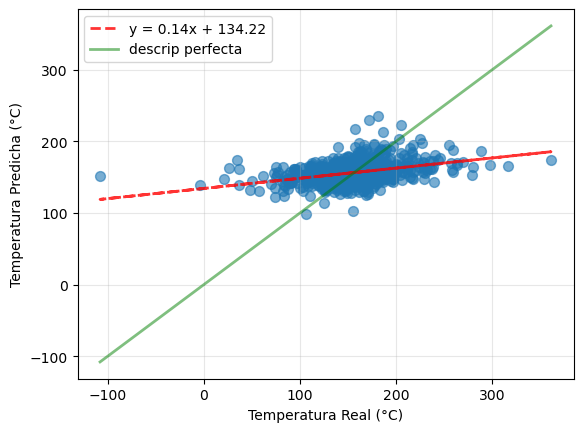

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


def variables_regresion(df, variable_objetivo, variables_predictoras):
    """
    completar documentacion
    """
    # quedarnos solo con las filas completas
    df_filtrado = df.copy()
    for var in variables_predictoras + [variable_objetivo]:
        df_filtrado = df_filtrado[df_filtrado[var] != -99]
    
    X = df_filtrado[variables_predictoras]
    y = df_filtrado[variable_objetivo]
    
    return X, y, variables_predictoras
# definir variable objetivo
variable_objetivo='Temperatura de Servicio °C, max'

# definir variables predictoras
variables_predictoras = [
        'Viscosidad del Aceite Base a 40°C. cSt',
        'Penetración de Cono a 25°C, 0.1mm', 
        'Punto de Gota, °C',
        'Punto de Soldadura Cuatro Bolas, kgf',
        'Grado NLGI Consistencia'
    ]


# pruebe
# expanded_data = simular_datos_vae(df, n_nuevos=1000)
# expanded_data = simular_datos_knn(df, n_nuevos=1000)
expanded_data = simular_datos_copula(df, n_nuevos=1000)

X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)
test_size = 0.1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
    
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)
    
# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# graficar
y_pred = y_pred_train
y_real = y_train

# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)
    
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2, 
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
    
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
    
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Ejercicios de simulacion y regresion
- Escriba una clase que le permita de manera expedita eligir cualquiera de los tres metodos

- Usted cree que la combinacion de 1 o mas metodos le pueda ser de ayuda? Combine varios metodos, puede usar `chatGPT` para hacer codigo en este punto. 
* Sí, creemos que usar varios metodos puede ayudar a capturar mejor la distribucion de los datos originales y generar datos sinteticos mas realistas. Por ejemplo, podemos usar KNN para capturar la estructura local de los datos y luego aplicar VAE para modelar la distribucion global. Esto puede resultar en datos sinteticos que reflejen mejor las caracteristicas de los datos originales.*

- Pruebe distintas combinaciones de variables, por ejemplo, preguntese que necesidad podria tener un cliente.
- ... es decir, un cliente le puede solo interesar la viscosidad, investigue el mercado!!
- Intente mejorar estos modificando o agregando parametros
- Agregue mas graficas de diagnostico para ver la efectividad de la regresion lineal
- En cada uno de los casos, escriba lo que le va a explicar al socio formador y el motivo de su simulacion

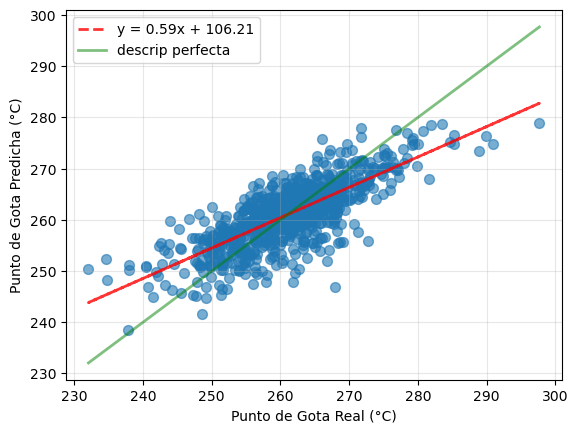

In [9]:
# Escriba una clase que le permita de manera expedita eligir cualquiera de los tres metodos
# --- IGNORE ---
class DataSimulator:
    def __init__(self, method='vae', **kwargs):
        self.method = method
        self.kwargs = kwargs

    def simulate(self, df_original, n_nuevos=100):
        if self.method == 'vae':
            return simular_datos_vae(df_original, n_nuevos=n_nuevos, **self.kwargs)
        elif self.method == 'knn':
            return simular_datos_knn(df_original, n_nuevos=n_nuevos, **self.kwargs)
        elif self.method == 'copula':
            return simular_datos_copula(df_original, n_nuevos=n_nuevos, **self.kwargs)
        else:
            raise ValueError(f"Unknown method: {self.method}")
# --- IGNORE ---
# definir variable objetivo
variable_objetivo='Punto de Gota, °C' 
# definir variables predictoras
variables_predictoras = [
        'Viscosidad del Aceite Base a 40°C. cSt',
        'Penetración de Cono a 25°C, 0.1mm', 
        'Temperatura de Servicio °C, max',
        'Punto de Soldadura Cuatro Bolas, kgf',
        'Grado NLGI Consistencia'
     ]
# pruebe
expanded_data = simular_datos_vae(df, n_nuevos=1000)
# expanded_data = simular_datos_knn(df, n_nuevos=1000)
# expanded_data = simular_datos_copula(df, n_nuevos=1000) --- IGNORE ---
X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras) 
test_size = 0.1 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size) 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 
modelo = LinearRegression() 
modelo.fit(X_train_scaled, y_train) 
y_pred_train = modelo.predict(X_train_scaled) 
y_pred_test = modelo.predict(X_test_scaled) 
# metricas
mse_train = mean_squared_error(y_train, y_pred_train) 
mse_test = mean_squared_error(y_test, y_pred_test) 
# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train) 
r2_test = r2_score(y_test, y_pred_test) 
# graficar
y_pred = y_pred_train 
y_real = y_train 
# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1) 
p = np.poly1d(z) 
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2,
              label=f'y = {z[0]:.2f}x + {z[1]:.2f}') 
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta') 
plt.xlabel('Punto de Gota Real (°C)') 
plt.ylabel('Punto de Gota Predicha (°C)') 
plt.legend() 
plt.grid(True, alpha=0.3) 

# --- IGNORE ---



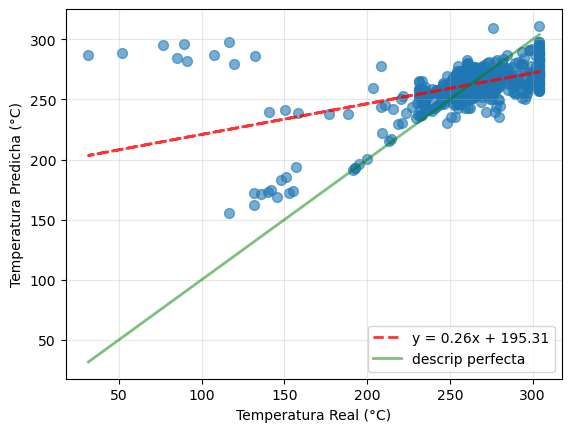

In [10]:
# combinar varios metodos, VAE + KNN
def simular_datos_combinado(df_original, n_nuevos=100):
    """
    documentar
    """
    n_nuevos_vae = n_nuevos // 2
    n_nuevos_knn = n_nuevos - n_nuevos_vae

    df_vae = simular_datos_vae(df_original, n_nuevos=n_nuevos_vae)
    df_knn = simular_datos_knn(df_original, n_nuevos=n_nuevos_knn)

    df_nuevo = pd.concat([df_vae, df_knn], ignore_index=True)
    return df_nuevo
# pruebe
# expanded_data = simular_datos_vae(df, n_nuevos=1000) --- IGNORE ---
# expanded_data = simular_datos_knn(df, n_nuevos=1000) --- IGNORE ---
# expanded_data = simular_datos_copula(df, n_nuevos=1000) --- IGNORE ---
expanded_data = simular_datos_combinado(df, n_nuevos=1000)
X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)
# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
# graficar
y_pred = y_pred_train
y_real = y_train
# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2, 
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
# --- IGNORE ---


# 5. Mejorando los datos
### 5.1 Un codificador caliente 🔥

La primera mejora que podemos hacer es las variables categoricas, no simplemente ponerlos como numeros enteros ordenados.


Ejercicios:
- Describa la utilidad de `OneHotEncoder`. (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

* OneHotEncoder es una tecnica de preprocesamiento de datos que convierte variables categoricas en una forma que puede ser proporcionada a algoritmos de aprendizaje automatico para mejorar su rendimiento. En lugar de asignar un numero entero a cada categoria, lo que puede implicar un orden o relacion entre ellas, OneHotEncoder crea una nueva columna para cada categoria y asigna un valor binario (0 o 1) para indicar la presencia o ausencia de esa categoria en cada fila. Esto evita que el modelo interprete las categorias como ordinales y permite capturar mejor las relaciones entre las variables categoricas y la variable objetivo.*

- Las siguientes lineas de codigo implementan este algoritmo reviselas y entiendalas
- Discuta si esta forma de transformar las variables categoricas puede ser util o no para el reto de Interlub.

* Sí, esta forma de transformar las variables categoricas puede ser util para el reto de Interlub, ya que permite capturar mejor las relaciones entre las variables categoricas y la variable objetivo sin introducir un orden o relacion indebida entre las categorias. Esto puede mejorar el rendimiento del modelo de regresion lineal al evitar interpretaciones incorrectas de las variables categoricas.*

- Escriba una funcion (similar a la asignacion de numeros enteros ) que haga esta implementacion, comente dicha funcion.
- Haga la generacion de datos y la regresion lineal y compare sus resultados con y sin esta implementacion


In [11]:
from sklearn.preprocessing import OneHotEncoder

# cargar data_set
df = pd.read_csv("datos_grasas_Tec_limpio.csv")
categorical_columns = ["color", "textura", "Espesante", "Aceite Base"]

ohe = OneHotEncoder(sparse_output=False, drop=None)
ohe_array = ohe.fit_transform(df[categorical_columns])
ohe_feature_names = ohe.get_feature_names_out(categorical_columns)
df_ohe = pd.DataFrame(ohe_array, columns=ohe_feature_names)
df_final = pd.concat([df.drop(columns=categorical_columns), df_ohe], axis=1)
# print(df_final.head())
df_final.to_csv("datos_one_hot.csv")


In [12]:
# Escriba una funcion (similar a la asignacion de numeros enteros ) que haga esta implementacion, comente dicha funcion.
def aplicar_one_hot_encoding(df, categorical_columns):
    """
    Esta funcion aplica OneHotEncoder a las columnas categoricas especificadas en el DataFrame dado.
    Crea nuevas columnas binarias para cada categoria y concatena estas columnas al DataFrame original,
    eliminando las columnas categoricas originales.
    
    Parametros:
    df: pd.DataFrame - El DataFrame original que contiene las columnas categoricas.
    categorical_columns: list - Una lista de nombres de columnas categoricas a transformar.
    
    Retorna:
    pd.DataFrame - El DataFrame modificado con las columnas categoricas transformadas en formato one-hot.
    """
    ohe = OneHotEncoder(sparse_output=False, drop=None)
    ohe_array = ohe.fit_transform(df[categorical_columns])
    ohe_feature_names = ohe.get_feature_names_out(categorical_columns)
    df_ohe = pd.DataFrame(ohe_array, columns=ohe_feature_names)
    df_final = pd.concat([df.drop(columns=categorical_columns), df_ohe], axis=1)
    return df_final
# cargar data_set
df = pd.read_csv("datos_grasas_Tec_limpio.csv")
categorical_columns = ["color", "textura", "Espesante", "Aceite Base"]
df_final = aplicar_one_hot_encoding(df, categorical_columns)
df_final.to_csv("datos_one_hot_funcion.csv")



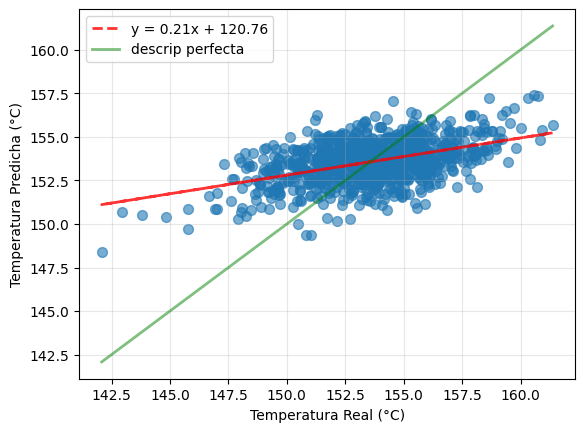

In [13]:
# Haga la generacion de datos y la regresion lineal y compare sus resultados con y sin esta implementacion, con la base de datos con OneHotEncoder
df = pd.read_csv("datos_one_hot_funcion.csv")
# definir variable objetivo
variable_objetivo='Temperatura de Servicio °C, max'
# definir variables predictoras
variables_predictoras = [
        'Viscosidad del Aceite Base a 40°C. cSt',
        'Punto de Soldadura Cuatro Bolas, kgf',
        'Grado NLGI Consistencia',
        'Desgaste Cuatro Bolas, mm'
    ]
# pruebe
# expanded_data = simular_datos_knn(df, n_nuevos=1000) 
# expanded_data = simular_datos_copula(df, n_nuevos=1000) --- IGNORE ---
expanded_data = simular_datos_vae(df, n_nuevos=1000)

#print("Columnas del df:", expanded_data.columns.tolist())
#missing = [v for v in variables_predictoras + [variable_objetivo] if v not in expanded_data.columns]
#print("Variables faltantes:", missing)

X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)
# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
# graficar
y_pred = y_pred_train
y_real = y_train
# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)

plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2,
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()],
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)


### 5.2. Descripciones en la base de datos con palabras 🗣️💬

La segunda mejora que podemos hacer es considerar las columnas que contiene informacion en palabras.

Ejercicios:
- Explique la funcion `CountVectorizer`. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

    * CountVectorizer es una tecnica de preprocesamiento de texto que convierte una coleccion de documentos de texto en una matriz de conteo de tokens. Cada fila de la matriz representa un documento y cada columna representa un token unico (palabra o n-grama) presente en el conjunto de documentos. El valor en cada celda indica la frecuencia con la que el token aparece en el documento correspondiente. Esta representacion numerica del texto permite a los algoritmos de aprendizaje automatico procesar y analizar datos textuales de manera efectiva.*

- Enumere sus parametros mas importantes y expliquelos:
    - `stop_words`: Permite especificar una lista de palabras que se deben ignorar durante el conteo, como palabras comunes que no aportan significado relevante.
    - `ngram_range`: Define el rango de n-gramas a considerar, por ejemplo, (1, 2) incluiria tanto palabras individuales como pares de palabras consecutivas.
    - `max_features`: Limita el numero de caracteristicas (tokens) a considerar, seleccionando las mas frecuentes hasta el numero especificado.
    - `lowercase`: Convierte todo el texto a minusculas antes del procesamiento para asegurar que las palabras se traten de manera uniforme.
    - `token_pattern`: Define la expresion regular utilizada para identificar los tokens en el texto.


- Discuta si esta forma de transformar las variables descriptivas puede ser util o no para el reto de Interlub.

    * Sí, esta forma de transformar las variables descriptivas puede ser util para el reto de Interlub, ya que permite extraer informacion relevante de las descripciones textuales y convertirla en una representacion numerica que puede ser utilizada por los algoritmos de aprendizaje automatico. Esto puede ayudar a capturar patrones y relaciones entre las descripciones y la variable objetivo, mejorando asi el rendimiento del modelo de regresion lineal.*

- Con ayuda de `chatGPT` implemente `CountVectorizer`. Documente claramente sus prompts para que el profesor y el socio formador puedan entender que y el por que de lo que implemento
- Haga la generacion de datos y la regresion lineal y compare sus resultados con y sin esta implementacion




In [14]:
# Implementacion de CountVectorizer
# --- IGNORE ---
from sklearn.feature_extraction.text import CountVectorizer
# Aplicamos CountVectorizer a las columnas de texto en un DataFrame
df = pd.read_csv("datos_grasas_Tec_limpio.csv")
text_columns = ["color", "textura", "Espesante", "Aceite Base"]
vectorizer = CountVectorizer()
for col in text_columns:
    X_counts = vectorizer.fit_transform(df[col].astype(str))
    count_feature_names = [f"{col}_{feat}" for feat in vectorizer.get_feature_names_out()]
    df_counts = pd.DataFrame(X_counts.toarray(), columns=count_feature_names)
    df = pd.concat([df.drop(columns=[col]), df_counts], axis=1)
# print(df.head())
df.to_csv("datos_count_vectorizer.csv")

In [15]:
# ...existing code...
from copulas.multivariate import GaussianMultivariate
import numpy as np
import pandas as pd

def simular_datos_copula_1(df_original, n_nuevos=100, verbose=False):
    """
    Fit GaussianMultivariate on numeric columns and sample synthetic rows.
    - Drops non-numeric columns
    - Replaces -99 with NaN and fills with column mean
    - Adds tiny jitter if fit fails due to singularity
    """
    # keep only numeric columns
    df_num = df_original.select_dtypes(include=[np.number]).copy()
    if df_num.empty:
        raise ValueError("No numeric columns available to fit the copula.")

    # replace placeholder values and fill NaNs
    df_num.replace(-99, np.nan, inplace=True)
    if df_num.isna().any().any():
        df_num.fillna(df_num.mean(), inplace=True)

    # basic checks
    if df_num.shape[0] < 2:
        raise ValueError("Too few rows to fit GaussianMultivariate (need >=2).")
    if df_num.shape[1] == 0:
        raise ValueError("No numeric columns to fit GaussianMultivariate.")

    model = GaussianMultivariate()
    try:
        model.fit(df_num)
    except Exception as e:
        if verbose:
            print("GaussianMultivariate.fit failed: ", e, " => retrying with jitter.")
        # add small noise and retry
        jitter = np.random.normal(scale=1e-8, size=df_num.shape)
        model.fit(df_num + jitter)

    df_nuevo = model.sample(n_nuevos)
    # ensure DataFrame
    if isinstance(df_nuevo, np.ndarray):
        df_nuevo = pd.DataFrame(df_nuevo, columns=df_num.columns)

    return df_nuevo
# ...existing code...

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value

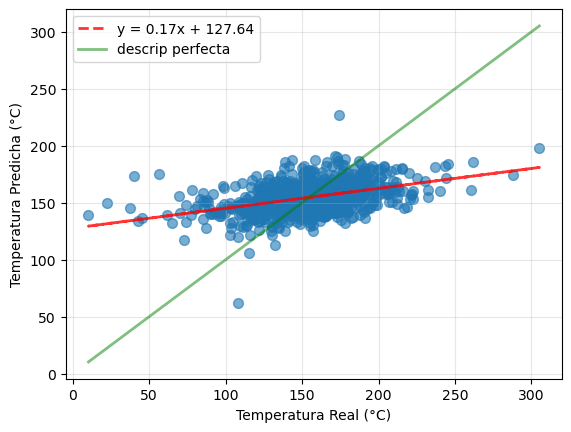

In [16]:
# Haga la generacion de datos y la regresion lineal y compare sus resultados con y sin esta implementacion, con la base de datos con CountVectorizer
# definir variable objetivo
variable_objetivo='Temperatura de Servicio °C, max'
# definir variables predictoras
variables_predictoras = [
        'Viscosidad del Aceite Base a 40°C. cSt',
        'Punto de Soldadura Cuatro Bolas, kgf',
        'Grado NLGI Consistencia',
        'Desgaste Cuatro Bolas, mm'
    ]
# pruebe
df = pd.read_csv("datos_count_vectorizer.csv")


#print("Columns:", df.columns.tolist())
#print(df.dtypes)
#print("Any -99 placeholders:", (df == -99).sum().sum())
#print("NA counts:", df.isna().sum())

# expanded_data = simular_datos_vae(df, n_nuevos=1000) --- IGNORE ---
# expanded_data = simular_datos_knn(df, n_nuevos=1000) --- IGNORE ---
expanded_data = simular_datos_copula_1(df, n_nuevos=1000)
X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)
# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
# graficar
y_pred = y_pred_train
y_real = y_train
# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2,
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()],
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# Adaptación a INTERLUB

Se llevo a cabo una basta y extensa investigación acerca de las variables de la base de datos proporcionada por Interlub. Esto con el propóstio de que se pudiera identificar una variable objetivo y otras variables predictoras con pruebas, información y fundamentos técnicos en la industria de grasas lubricantes. Esto para adaptar este problema a un caso más real y aplicativo para la empresa. Creemos que es valioso para el socio formador saber como funcionaría este modelo de regresión lineal pero aplicado a un contexto más realista de la industria.

Después de investigar las variables disponibles en la base de datos proporcionada por Interlub, se identificó que la variable objetivo más relevante para predecir el rendimiento de las grasas lubricantes es la "Punto de Gota, °C". Es la temperatura a la cual la grasa pierde su estructura (la red del espesante colapsa). En la industria es el indicador primario de calidad térmica, definido en ASTM D566/D2265. Es el parámetro más crítico, más influyente y más sensible en la formulación de grasas. Los demás parámetros dependen fuertemente de él o lo condicionan.

A continuación se aplicará el modelo de regresión lineal, utilizando la funcion copula (simulación con copulas gaussianas) para predecir el "Punto de Gota, °C" a partir de las siguientes variables predictoras seleccionadas por su relevancia técnica en la industria.

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value

MSE Train: 1334.182695787114, MSE Test: 1577.543798778276
R2 Train: 0.33281059733851703, R2 Test: 0.41186496843440823


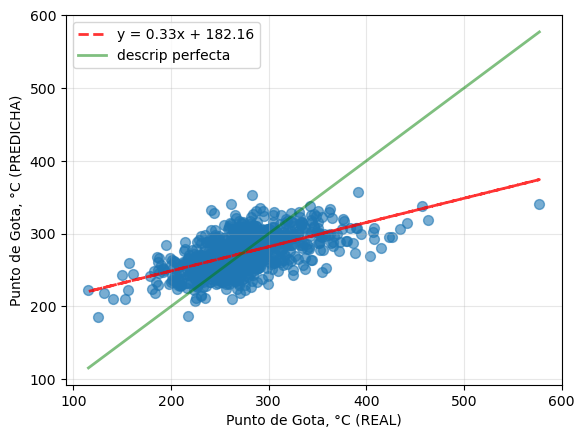

In [21]:
# Haga la generacion de datos combinando VAE y KNN con la base de datos con CountVectorizer
# definir variable objetivo
variable_objetivo='Punto de Gota, °C'
# definir variables predictoras
variables_predictoras = [
        'Viscosidad del Aceite Base a 40°C. cSt',
        'Punto de Soldadura Cuatro Bolas, kgf',
        'Grado NLGI Consistencia',
        'Estabilidad Mecánica, %',
        'Desgaste Cuatro Bolas, mm',
        'Temperatura de Servicio °C, max',
        'Resistencia al Lavado por Agua a 80°C, %'
    ]



# simulamos los datos combinados y utilizamos la base de datos con CountVectorizer
df = pd.read_csv("datos_count_vectorizer.csv")
# convertir las columnas 'Punto de Gota, °C', 'Estabilidad Mecánica, %', 'Resistencia al Lavado por Agua a 80°C, %' a numéricas
df['Punto de Gota, °C'] = pd.to_numeric(df['Punto de Gota, °C'], errors='coerce')
df['Estabilidad Mecánica, %'] = pd.to_numeric(df['Estabilidad Mecánica, %'], errors='coerce')
df['Resistencia al Lavado por Agua a 80°C, %'] = pd.to_numeric(df['Resistencia al Lavado por Agua a 80°C, %'], errors='coerce')

expanded_data = simular_datos_copula_1(df, n_nuevos=1000)


# se obitienen las variables predictoras y la variable objetivo
X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras) 

# dividmos el data set en train y test
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

# estandarizamos los datos de entrada
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# definimos y entrenamos el modelo de regresion lineal
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

# hacemos predicciones con el modelo 
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)

# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"MSE Train: {mse_train}, MSE Test: {mse_test}")

# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"R2 Train: {r2_train}, R2 Test: {r2_test}")

# graficar
y_pred = y_pred_train
y_real = y_train
# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2, 
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
plt.xlabel('Punto de Gota, °C (REAL)')
plt.ylabel('Punto de Gota, °C (PREDICHA)')
plt.legend()
plt.grid(True, alpha=0.3)
# --- IGNORE ---


MSE Train: 10.305371674383439, MSE Test: 11.507970049984008
R2 Train: 0.5699328941914814, R2 Test: 0.4431382129314453


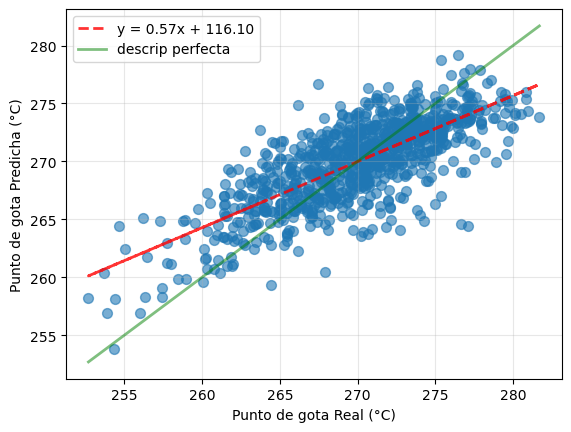

In [18]:
# Haga la generacion de datos y la regresion lineal y compare sus resultados con y sin esta implementacion, con la base de datos con OneHotEncoder
df = pd.read_csv("datos_one_hot_funcion.csv")

df['Punto de Gota, °C'] = pd.to_numeric(df['Punto de Gota, °C'], errors='coerce')
df['Estabilidad Mecánica, %'] = pd.to_numeric(df['Estabilidad Mecánica, %'], errors='coerce')
df['Resistencia al Lavado por Agua a 80°C, %'] = pd.to_numeric(df['Resistencia al Lavado por Agua a 80°C, %'], errors='coerce')

# definir variable objetivo
variable_objetivo='Punto de Gota, °C'
# definir variables predictoras
variables_predictoras = [
        'Viscosidad del Aceite Base a 40°C. cSt',
        'Punto de Soldadura Cuatro Bolas, kgf',
        'Grado NLGI Consistencia',
        'Estabilidad Mecánica, %',
        'Desgaste Cuatro Bolas, mm',
        'Temperatura de Servicio °C, max',
        'Resistencia al Lavado por Agua a 80°C, %'
    ]
# pruebe
# expanded_data = simular_datos_knn(df, n_nuevos=1000) 
# expanded_data = simular_datos_copula(df, n_nuevos=1000)
expanded_data = simular_datos_vae(df, n_nuevos=1000)


# se obitienen las variables predictoras y la variable objetivo
X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)

# dividmos el data set en train y test
test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

# estandarizamos los datos de entrada
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# definimos y entrenamos el modelo de regresion lineal
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)

# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"MSE Train: {mse_train}, MSE Test: {mse_test}")

# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"R2 Train: {r2_train}, R2 Test: {r2_test}")

# graficar
y_pred = y_pred_train
y_real = y_train
# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)

plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2,
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()],
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
plt.xlabel('Punto de gota Real (°C)')
plt.ylabel('Punto de gota Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)


MSE Train: 16.753848161980326, MSE Test: 17.004260935488947
R2 Train: 0.6658755328415505, R2 Test: 0.5991942572030743


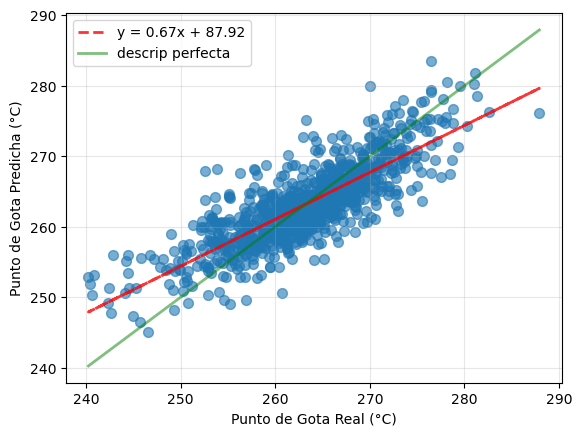

In [20]:
df = pd.read_csv("transformed_data_interlub.csv")
# definir variable objetivo
variable_objetivo='Punto de Gota, °C' 
# definir variables predictoras
variables_predictoras = [
        'Viscosidad del Aceite Base a 40°C. cSt',
        'Punto de Soldadura Cuatro Bolas, kgf',
        'Grado NLGI Consistencia',
        'Estabilidad Mecánica, %',
        'Desgaste Cuatro Bolas, mm',
        'Temperatura de Servicio °C, max',
        'Resistencia al Lavado por Agua a 80°C, %'
     ]
# pruebe
expanded_data = simular_datos_vae(df, n_nuevos=1000)
# expanded_data = simular_datos_knn(df, n_nuevos=1000)
# expanded_data = simular_datos_copula(df, n_nuevos=1000) 

# se obitienen las variables predictoras y la variable objetivo
X, y, features = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)

# dividmos el data set en train y test
test_size = 0.1 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

# estandarizamos los datos de entrada
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

# definimos y entrenamos el modelo de regresion lineal
modelo = LinearRegression() 
modelo.fit(X_train_scaled, y_train) 
y_pred_train = modelo.predict(X_train_scaled) 
y_pred_test = modelo.predict(X_test_scaled) 


# metricas
mse_train = mean_squared_error(y_train, y_pred_train) 
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"MSE Train: {mse_train}, MSE Test: {mse_test}")


# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train) 
r2_test = r2_score(y_test, y_pred_test)
print(f"R2 Train: {r2_train}, R2 Test: {r2_test}")


# graficar
y_pred = y_pred_train 
y_real = y_train 
# linea de regresion para las predicciones
z = np.polyfit(y_real, y_pred, 1) 
p = np.poly1d(z) 
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2,
              label=f'y = {z[0]:.2f}x + {z[1]:.2f}') 
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta') 
plt.xlabel('Punto de Gota Real (°C)') 
plt.ylabel('Punto de Gota Predicha (°C)') 
plt.legend() 
plt.grid(True, alpha=0.3) 



